---
title: "Combinatorial Optimization with Decoded Quantum Interferometry"
author: "Dominik Arnold, Adapted by Adelina Bärligea"
date: "2026-08-21"
categories: [code]
image: "DQImaxCutPreview.png"
image-width: "1cm"
image-height: "1cm"
format:
  html:
    code-fold: false
    eval: true
    embed-resources: true
toc: true
jupyter: blogqa
---


In this tutorial, we implement Decoded Quantum Interferometry (DQI) proposed by [Jordan et al. 2025](https://doi.org/10.1038/s41586-025-09527-5) for a small MaxCut instance using [Tequila](https://github.com/tequilahub/tequila). DQI uses interference to bias measurement outcomes toward strings with large objective values and reduces an important part of the quantum-state preparation to a classical syndrome-decoding problem.

We will formulate MaxCut as max-2-XORSAT, construct the DQI circuit register by register, evaluate its exact ideal output distribution, and compare it with uniform random sampling. Note that the example is deliberately small and uses a complete lookup-table decoder, as this is a tutorial about the mechanism of DQI, not a scalability benchmark or a demonstration of quantum advantage.


In [1]:
import numpy as np
import networkx as nx
import tequila as tq
import matplotlib.pyplot as plt

from itertools import combinations
from math import ceil, comb, log2, sqrt

SEED = 7
rng = np.random.default_rng(SEED)

## The MaxCut problem

Given an undirected graph $G=(V,E)$, MaxCut asks us to partition the vertices into two sets so that as many edges as possible connect different sets. We represent a cut by a bit string $\mathbf{x}\in\{0,1\}^{|V|}$: vertices $u$ and $v$ lie on different sides exactly when $x_u\oplus x_v=1$.

For every edge $(u,v)$, we therefore introduce the binary equation

$$
x_u+x_v=1\pmod 2.
$$

Collecting the edge equations gives $B\mathbf{x}=\mathbf{v}$ over $\mathbb{F}_2$, where each row of $B$ contains a one at the two endpoints of one edge and $\mathbf{v}$ is the all-ones vector. The number of satisfied equations is precisely the value of the cut. Thus MaxCut is the max-2-XORSAT special case of the max-XORSAT problems addressed by DQI.


For our demonstration, we use a Petersen graph with $n=10$ vertices, $m=15$ edges, and girth five. For its incidence matrix, the code

$$
C^\perp=\{\mathbf{y}\in\mathbb{F}_2^m:B^\top\mathbf{y}=0\}
$$

is the graph's cycle code, whose minimum distance $d^\perp$ equals the girth. Hence every error of Hamming weight at most $\ell=2$ has a unique syndrome and can be decoded exactly in this example. The Petersen graph is also the smallest 3-regular graph with girth five, making it a compact and visually recognizable test case.


Vertices in graph: 10
Edges in graph:    15
Girth:             5


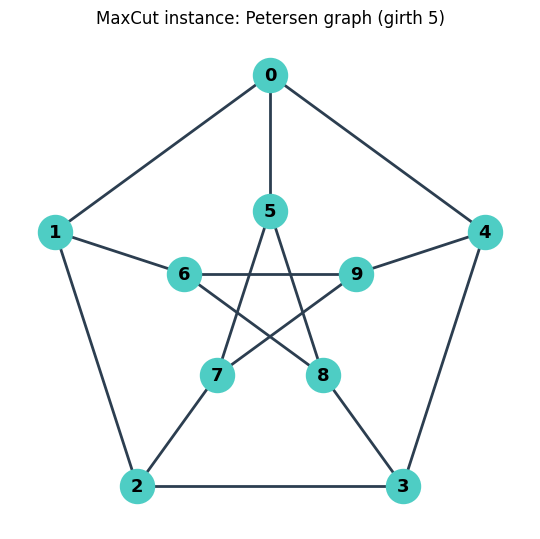

In [2]:
Graph = nx.petersen_graph()
n = Graph.number_of_nodes()
m = Graph.number_of_edges()
girth = nx.girth(Graph)

print("Vertices in graph:", n)
print("Edges in graph:   ", m)
print("Girth:            ", girth)


def petersen_layout():
    """Return the familiar pentagon-in-pentagram layout."""
    pos = {}
    for i in range(5):
        angle = np.pi / 2 + 2 * np.pi * i / 5
        pos[i] = (2 * np.cos(angle), 2 * np.sin(angle))
    for i in range(5):
        angle = np.pi / 2 + 2 * np.pi * i / 5
        pos[i + 5] = (0.8 * np.cos(angle), 0.8 * np.sin(angle))
    return pos


pos = petersen_layout()
fig, ax = plt.subplots(figsize=(5.5, 5.5))
nx.draw(
    Graph,
    pos,
    ax=ax,
    with_labels=True,
    node_color="#4ECDC4",
    node_size=600,
    font_size=13,
    font_weight="bold",
    edge_color="#2C3E50",
    width=2,
)
ax.set_title(f"MaxCut instance: Petersen graph (girth {girth})")
plt.tight_layout()
plt.show()

We now build the constraint matrix. The row corresponding to edge $(u,v)$ has $B_{i,u}=B_{i,v}=1$, while all other entries vanish.


In [3]:
edges = list(Graph.edges())

B = np.zeros((m, n), dtype=int)
for row, (u, v_node) in enumerate(edges):
    B[row, u] = 1
    B[row, v_node] = 1

v_vec = np.ones(m, dtype=int)
B_T = B.T

print("Constraint matrix B (m x n):")
print(B)

Constraint matrix B (m x n):
[[1 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 1 0 0 0 0]
 [0 1 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 1 0 0 0]
 [0 0 1 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 1 0 0]
 [0 0 0 1 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 0 1 0 0 1 0]
 [0 0 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 0 1 0 0 1]
 [0 0 0 0 0 0 0 1 0 1]]


Because this instance is small, we can enumerate all $2^n$ cuts once. This gives us an exact optimum against which we can check the sampled DQI solutions later.


In [4]:
def maxcut_value(x, graph=Graph):
    """Return the number of graph edges cut by a binary assignment."""
    return sum(1 for u, v in graph.edges() if x[u] != x[v])


bestCut, best_x = 0, None
for integer in range(2**n):
    x = np.array([(integer >> bit) & 1 for bit in range(n)])
    cut = maxcut_value(x)
    if cut > bestCut:
        bestCut, best_x = cut, x.copy()

print(f"Exact optimum: {bestCut} cut edges")
print(f"One optimal assignment: {best_x}")

Exact optimum: 12 cut edges
One optimal assignment: [0 0 1 0 1 1 1 0 0 0]


## Decoded Quantum Interferometry

For max-XORSAT, let $s(\mathbf{x})$ be the number of satisfied constraints and define the centered objective

$$
f(\mathbf{x})=2s(\mathbf{x})-m.
$$

DQI prepares a normalized state of the form

$$
|P(f)\rangle
=\frac{1}{\mathcal{N}}\sum_{\mathbf{x}\in\mathbb{F}_2^n}
P(f(\mathbf{x}))|\mathbf{x}\rangle,
$$

where $P$ is a degree-$\ell$ polynomial chosen so that high-objective strings receive larger measurement probability. Rather than evaluating $P(f)$ directly, DQI prepares its sparse Fourier representation and transforms back to the solution basis.

The algorithm uses three distinct registers:

| Register | Size | Role |
|---|---:|---|
| Weight | $\lceil\log_2(\ell+1)\rceil$ | Coherently labels the Hamming weight $k\in\{0,\ldots,\ell\}$ |
| Error | $m$ | Stores low-weight strings $\mathbf{y}\in\mathbb{F}_2^m$ |
| Syndrome / solution | $n$ | First stores $B^\top\mathbf{y}$ and becomes the sampled solution after the Hadamard transform |

The circuit will create the low-weight superposition

$$
\sum_{k=0}^{\ell}\frac{w_k}{\sqrt{\binom{m}{k}}}
\sum_{|\mathbf{y}|=k}(-1)^{\mathbf{v}\cdot\mathbf{y}}
|\mathbf{y}\rangle|B^\top\mathbf{y}\rangle,
$$

decode $\mathbf{y}$ from its syndrome to uncompute the error register, and finally apply $H^{\otimes n}$ to the syndrome register. We split this construction into eight concrete steps below.


In [5]:
l = 2  # Polynomial degree ell and maximum decoded Hamming weight
weightQubits = int(ceil(log2(l + 1)))
errorQubits = m
syndromeQubits = n
totalQubits = weightQubits + errorQubits + syndromeQubits

W = list(range(weightQubits))
E = list(range(weightQubits, weightQubits + errorQubits))
S = list(range(weightQubits + errorQubits, totalQubits))

print(f"Weight register:   {weightQubits} qubits")
print(f"Error register:    {errorQubits} qubits")
print(f"Syndrome register: {syndromeQubits} qubits")
print(f"Total simulation:  {totalQubits} qubits")

Weight register:   2 qubits
Error register:    15 qubits
Syndrome register: 10 qubits
Total simulation:  27 qubits


## Solving MaxCut with DQI

### Step 1: Embed the weight register

The coefficients $w_k$ are obtained from the principal eigenvector of the symmetric tridiagonal matrix

$$
A^{(m,\ell,d)}=
\begin{pmatrix}
0 & a_1 & & & \\
a_1 & d & a_2 & & \\
& a_2 & 2d & \ddots & \\
& & \ddots & \ddots & a_\ell \\
& & & a_\ell & \ell d
\end{pmatrix},
$$

with

$$
a_k=\sqrt{k(m-k+1)},
\qquad
d=\frac{p-2r}{\sqrt{r(p-r)}}.
$$

Here $p=2$ because we work over $\mathbb{F}_2$, and $r=1$ because each edge equation accepts one of the two field values. Consequently, $d=0$. Under the strict distance condition $2\ell+1<d^\perp$, the principal eigenvector is the optimal coefficient vector and the corresponding expected number of satisfied constraints is

$$
\mathbb{E}[s]
=\frac{mr}{p}+\frac{\sqrt{r(p-r)}}{p}\lambda_{\max}(A).
$$


In [6]:
def optimalWeights(m, l, p=2, r=1):
    """Return the principal-eigenvector weights and spectrum of A."""
    d = (p - 2 * r) / sqrt(r * (p - r))

    main_diag = np.diag(np.arange(l + 1) * d)
    off_diag = np.sqrt(
        np.arange(1, l + 1) * (m - np.arange(1, l + 1) + 1)
    )
    A = main_diag + np.diag(off_diag, 1) + np.diag(off_diag, -1)

    eigenvalues, eigenvectors = np.linalg.eigh(A)
    w_k = np.abs(eigenvectors[:, -1])
    return w_k, eigenvalues, A


w_k, eigenvalues, A = optimalWeights(m, l)
lambda_max = eigenvalues[-1]
referenceScore = m / 2 + lambda_max / 2

print("A =")
print(A)
print(f"Optimal weights: {w_k}")
print(f"Tridiagonal-model reference score: {referenceScore:.6f}")

A =
[[0.         3.87298335 0.        ]
 [3.87298335 0.         5.29150262]
 [0.         5.29150262 0.        ]]
Optimal weights: [0.41763453 0.70710678 0.5705974 ]
Tridiagonal-model reference score: 10.778719


For this example,

$$
A=
\begin{pmatrix}
0 & \sqrt{15} & 0 \\
\sqrt{15} & 0 & 2\sqrt{7} \\
0 & 2\sqrt{7} & 0
\end{pmatrix}.
$$

A subtle but useful caveat is visible already: the Petersen cycle code has $d^\perp=5$, while $2\ell+1=5$. The strict condition required by the finite-size expectation formula is therefore not satisfied. We may still use the principal eigenvector to choose the weights, and all errors of weight at most two remain uniquely decodable because $2\ell<d^\perp$. However, the printed reference score is **not** an exact prediction for this particular graph. We will compute the circuit's exact expectation directly from its output state below.

Since $\ell=2$, the weight register has two qubits and only needs to encode the three amplitudes $w_0,w_1,w_2$; the unused fourth computational-basis state receives zero amplitude.


In [7]:
def embedWeights(w_k, W):
    """Prepare w_0|0> + w_1|1> + w_2|2> on two qubits."""
    padded = np.zeros(4)
    padded[: len(w_k)] = w_k
    a, b, c, d = padded
    q0, q1 = W

    n0 = sqrt(a**2 + b**2)
    n1 = sqrt(c**2 + d**2)

    theta0 = 2 * np.arccos(np.clip(n0, -1, 1))
    theta1 = 2 * np.arccos(np.clip(a / n0, -1, 1))
    theta2 = 2 * np.arccos(np.clip(c / n1, -1, 1))

    circ = tq.QCircuit()
    circ += tq.gates.Ry(angle=theta0, target=q0)
    circ += tq.gates.X(target=q0)
    circ += tq.gates.Ry(angle=theta1, target=q1, control=q0)
    circ += tq.gates.X(target=q0)
    circ += tq.gates.Ry(angle=theta2, target=q1, control=q0)
    return circ


step1 = embedWeights(w_k, W)
wfn1 = tq.simulate(step1, backend="qulacs")
print("Prepared weight-register state:")
print(wfn1)

Prepared weight-register state:
+0.4176 |00> +0.5706 |10> +0.7071 |01> 


### Step 2: Prepare Dicke states

A Dicke state $|D_k^m\rangle$ is the uniform superposition of all $m$-bit strings with exactly $k$ ones:

$$
|D_k^m\rangle
=\frac{1}{\sqrt{\binom{m}{k}}}
\sum_{|\mathbf{y}|=k}|\mathbf{y}\rangle.
$$

We prepare these states using the [Bärtschi-Eidenbenz construction](https://arxiv.org/abs/1904.07358), built from **Split and Cyclic Shift (SCS)** unitaries. Each SCS unitary distributes an excitation across a growing window of qubits through controlled $R_y$ rotations. The weight register first initializes the appropriate number of excitations, after which the Dicke-state circuit spreads them uniformly over the error register.


In [8]:
def SCS(m_val, k, qubits):
    circ = tq.QCircuit()
    qs = qubits[:m_val]
    ql = qs[-1]
    qsl = qs[-2]
    theta1 = 2 * np.arccos(sqrt(1.0 / m_val))

    circ += tq.gates.CNOT(target=ql, control=qsl)
    circ += tq.gates.Ry(angle=theta1, target=qsl, control=ql)
    circ += tq.gates.CNOT(target=ql, control=qsl)

    for j in range(2, k + 1):
        qt = qs[-(j + 1)]
        qc2 = qs[-j]
        theta2 = 2 * np.arccos(sqrt(j / m_val))
        circ += tq.gates.CNOT(target=ql, control=qt)
        circ += tq.gates.Ry(angle=theta2, target=qt, control=[ql, qc2])
        circ += tq.gates.CNOT(target=ql, control=qt)
    return circ


def dicke(m_val, l, qubits):
    circ = tq.QCircuit()
    for q in range(m_val, l, -1):
        circ += SCS(q, l, qubits)
    for q in range(l, 1, -1):
        circ += SCS(q, q - 1, qubits)
    return circ


def buildDicke(W, E, l):
    circ = tq.QCircuit()
    q0, q1 = W

    # Initialize zero, one, or two excitations according to |k>.
    circ += tq.gates.CNOT(target=E[-1], control=q0)
    circ += tq.gates.CNOT(target=E[-1], control=q1)
    circ += tq.gates.CNOT(target=E[-2], control=q0)
    circ += dicke(len(E), l, E)
    return circ


step2 = buildDicke(W, E, l)

### Step 3: Uncompute the weight register

The weight label $|k\rangle$ is now redundant because $k$ equals the Hamming weight of the error string $\mathbf{y}$. We temporarily reverse the Dicke-state preparation, use the original excitation pattern to clear the weight qubits, and then reapply the Dicke circuit. This disentangles the weight register and returns it to $|00\rangle$.


In [9]:
def uncompute(W, E, l):
    circ = tq.QCircuit()
    dicke_U = dicke(len(E), l, E)

    circ += dicke_U.dagger()
    circ += tq.gates.CNOT(target=W[0], control=E[-2])
    circ += tq.gates.CNOT(target=W[1], control=E[-1])
    circ += tq.gates.CNOT(target=W[1], control=E[-2])
    circ += dicke_U
    return circ


step3 = uncompute(W, E, l)

### Step 4: Encode the constraint vector

We next imprint the phase $(-1)^{\mathbf{v}\cdot\mathbf{y}}$. A Pauli-$Z$ gate on error qubit $i$ contributes a minus sign exactly when $y_i=1$. Because $\mathbf{v}$ is the all-ones vector for MaxCut, we apply $Z$ to every error qubit.


In [10]:
encode = tq.QCircuit()
for q in E:
    encode += tq.gates.Z(target=q)

step4 = encode

### Step 5: Compute the syndrome

Reversible matrix-vector multiplication over $\mathbb{F}_2$ computes $B^\top\mathbf{y}$ into the syndrome register. Every nonzero entry $(B^\top)_{j,i}=1$ becomes a CNOT from error qubit $i$ to syndrome qubit $j$.


In [11]:
def syndrome(B_T, E, S):
    circ = tq.QCircuit()
    for j in range(B_T.shape[0]):
        for i in range(B_T.shape[1]):
            if B_T[j, i] == 1:
                circ += tq.gates.CNOT(target=S[j], control=E[i])
    return circ


step5 = syndrome(B_T, E, S)

### Step 6: Decode and uncompute the error register

The central algorithmic step is to infer the low-weight error $\mathbf{y}$ from its syndrome $\mathbf{s}=B^\top\mathbf{y}$. Our graph is small enough that we can enumerate every error of weight at most $\ell=2$ and store the inverse map in a lookup table.

Because the cycle-code distance is five, no two such errors share a syndrome. The table therefore contains

$$
\sum_{k=0}^{2}\binom{15}{k}=121
$$

entries. The multi-controlled operations below are a transparent reversible realization of that table, but they do not scale efficiently. Larger DQI applications require a decoder suited to the code family, such as belief propagation for suitable LDPC codes or an algebraic decoder for structured codes.


In [12]:
zero_syndrome = tuple(np.zeros(n, dtype=int))
syndromeTable = {zero_syndrome: np.zeros(m, dtype=int)}

for k in range(1, l + 1):
    for positions in combinations(range(m), k):
        y = np.zeros(m, dtype=int)
        y[list(positions)] = 1
        s = tuple((B_T @ y) % 2)
        if s in syndromeTable:
            raise ValueError("Low-weight errors do not have unique syndromes.")
        syndromeTable[s] = y.copy()

expectedEntries = sum(comb(m, k) for k in range(l + 1))
assert len(syndromeTable) == expectedEntries
print(f"Lookup table: {len(syndromeTable)} unique syndromes")


def decoding(syndromeTable, E, S):
    circ = tq.QCircuit()
    n_syn = len(S)

    for i in range(len(E)):
        for s, y in syndromeTable.items():
            if y[i] != 1:
                continue
            zeros = [j for j in range(n_syn) if s[j] == 0]
            for j in zeros:
                circ += tq.gates.X(target=S[j])
            circ += tq.gates.X(target=E[i], control=S)
            for j in zeros:
                circ += tq.gates.X(target=S[j])
    return circ


step6 = decoding(syndromeTable, E, S)

Lookup table: 121 unique syndromes


### Step 7: Apply the Hadamard transform

After the error register has been cleared, only the superposition of syndromes remains. Over $\mathbb{F}_2^n$, the quantum Fourier transform is the $n$-qubit Hadamard transform:

$$
H^{\otimes n}|\mathbf{s}\rangle
=\frac{1}{\sqrt{2^n}}
\sum_{\mathbf{x}\in\mathbb{F}_2^n}
(-1)^{\mathbf{s}\cdot\mathbf{x}}|\mathbf{x}\rangle.
$$

Interference among the syndrome amplitudes produces the desired objective-dependent distribution over candidate cuts.


In [13]:
def Hadamard(S):
    circ = tq.QCircuit()
    for q in S:
        circ += tq.gates.H(target=q)
    return circ


step7 = Hadamard(S)

### Step 8: Evaluate the solution distribution

The seven blocks below define the complete tequila circuit. A direct state-vector simulation uses 27 qubits, however, and can take many minutes and several gigabytes of memory. We therefore keep the full simulation as an optional validation and use an exact, compact calculation by default.

Immediately before the final Hadamards, every decoded error $\mathbf{y}$ contributes amplitude

$$
\frac{w_{|\mathbf{y}|}}{\sqrt{\binom{m}{|\mathbf{y}|}}}
(-1)^{\mathbf{v}\cdot\mathbf{y}}
$$

to the syndrome $B^\top\mathbf{y}$. Applying the Hadamard formula from Step 7 gives the output amplitudes without allocating the full work registers. This is an exact evaluation of the ideal circuit, not a new approximation; it simply exploits the uncomputation that we designed into Steps 3 and 6.


In [14]:
dqi = step1 + step2 + step3 + step4 + step5 + step6 + step7


def exact_dqi_distribution(B_T, v_vec, syndromeTable, w_k):
    """Evaluate the ideal solution amplitudes after the final Hadamards."""
    assignments = np.array(
        [
            [(integer >> j) & 1 for j in range(B_T.shape[0])]
            for integer in range(2 ** B_T.shape[0])
        ],
        dtype=int,
    )
    amplitudes = np.zeros(len(assignments), dtype=float)

    for y in syndromeTable.values():
        weight = int(np.sum(y))
        syndrome_bits = (B_T @ y) % 2
        encoding_phase = (-1.0) ** int((v_vec @ y) % 2)
        hadamard_phases = (-1.0) ** ((assignments @ syndrome_bits) % 2)
        amplitudes += (
            w_k[weight]
            * encoding_phase
            * hadamard_phases
            / sqrt(comb(len(y), weight))
        )

    amplitudes /= sqrt(len(assignments))
    probabilities = np.abs(amplitudes) ** 2
    assert np.isclose(probabilities.sum(), 1.0, atol=1e-12)
    return assignments, probabilities


assignments, probabilities = exact_dqi_distribution(
    B_T, v_vec, syndromeTable, w_k
)
print(f"Solution probability mass: {probabilities.sum():.12f}")

Solution probability mass: 1.000000000000


To verify the complete tequila implementation as well, set `RUN_FULL_STATEVECTOR = True` below. The resulting distribution must agree with the compact calculation, while any probability outside the all-zero work-register state diagnoses failed uncomputation. This check is disabled by default so that the tutorial remains comfortable to run on a laptop.


In [15]:
RUN_FULL_STATEVECTOR = False

if RUN_FULL_STATEVECTOR:
    wfn = tq.simulate(dqi, backend="qulacs")
    simulatedProbabilities = np.zeros(2**n)
    ancillaLeakage = 0.0
    workQubits = weightQubits + errorQubits
    workMask = (1 << workQubits) - 1

    for bs, amp in wfn.items():
        integer = bs.integer if hasattr(bs, "integer") else int(bs)
        probability = abs(amp) ** 2
        if integer & workMask:
            ancillaLeakage += probability
        solutionInteger = (integer >> workQubits) & ((1 << n) - 1)
        simulatedProbabilities[solutionInteger] += probability

    assert ancillaLeakage < 1e-10
    assert np.allclose(
        simulatedProbabilities, probabilities, atol=1e-10
    )
    print(f"Work-register leakage: {ancillaLeakage:.2e}")
    print("Full state-vector simulation agrees with the compact result.")
else:
    print("Full 27-qubit state-vector validation skipped.")


Full 27-qubit state-vector validation skipped.


We can now inspect the output in two complementary ways. First, we compute the exact expected cut value from the ideal probability distribution. Second, we draw a finite number of samples, as one would do when executing the circuit repeatedly, and compare them with uniformly random bit strings.


In [16]:
cutValues = np.array([maxcut_value(x) for x in assignments])
exactDqiMean = probabilities @ cutValues

shots = 10_000
dqiSamples = rng.choice(2**n, size=shots, p=probabilities)
dqiCuts = cutValues[dqiSamples]

randomAssignments = rng.integers(0, 2, size=(shots, n))
randCuts = [maxcut_value(x) for x in randomAssignments]

print(f"Tridiagonal reference: {referenceScore:.3f}")
print(f"Exact DQI expectation: {exactDqiMean:.3f}")
print(f"Sampled DQI average:   {np.mean(dqiCuts):.3f}")
print(f"Random average:        {np.mean(randCuts):.3f}")
print(f"Exact optimum:         {bestCut}")


Tridiagonal reference: 10.779
Exact DQI expectation: 10.221
Sampled DQI average:   10.234
Random average:        7.496
Exact optimum:         12


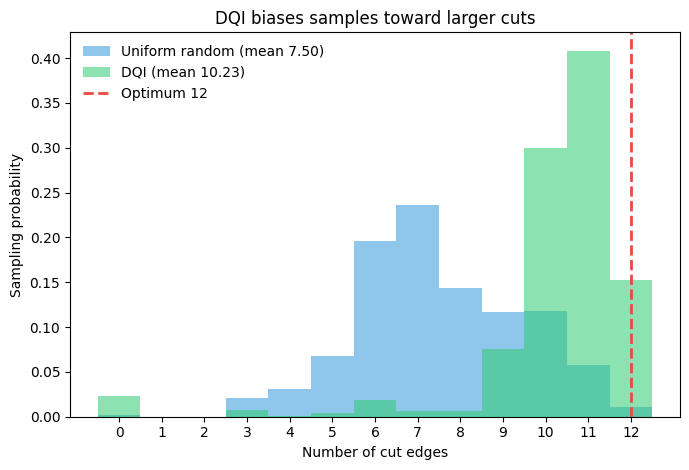

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.8))

minCut = min(min(randCuts), min(dqiCuts))
maxObservedCut = max(max(randCuts), max(dqiCuts))
bins = np.arange(minCut - 0.5, maxObservedCut + 1.5, 1)

ax.hist(
    randCuts,
    bins=bins,
    alpha=0.55,
    color="#3498DB",
    density=True,
    label=f"Uniform random (mean {np.mean(randCuts):.2f})",
)
ax.hist(
    dqiCuts,
    bins=bins,
    alpha=0.55,
    color="#2ECC71",
    density=True,
    label=f"DQI (mean {np.mean(dqiCuts):.2f})",
)
ax.axvline(
    bestCut,
    color="#E74C3C",
    linestyle="--",
    linewidth=2,
    label=f"Optimum {bestCut}",
)
ax.set_xticks(range(minCut, maxObservedCut + 1))
ax.set_xlabel("Number of cut edges")
ax.set_ylabel("Sampling probability")
ax.set_title("DQI biases samples toward larger cuts")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


DQI clearly shifts probability from typical random cuts toward higher-quality cuts. The exact expectation computed from the state also agrees with the finite-shot estimate.

The exact DQI value is lower than the tridiagonal reference value. This is not sampling error: it is a consequence of using the principal-eigenvector formula exactly at $2\ell+1=d^\perp$, outside the theorem's strict distance regime. The example is therefore useful in two ways: it demonstrates the DQI circuit and also shows why the assumptions behind an analytic performance expression must be checked on the chosen instance.

Finally, we select the best sampled assignment and visualize the corresponding partition.


Best solution found in DQI samples:
  x = [1 0 1 0 1 0 1 1 1 0]
  Cut = 12/12
  Partition 0: [1 3 5 9]
  Partition 1: [0 2 4 6 7 8]


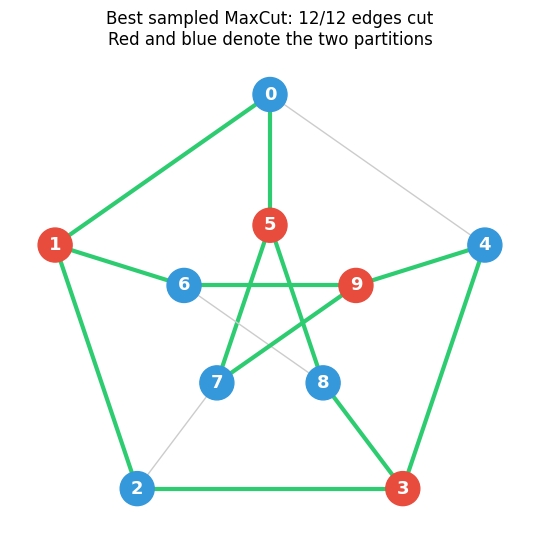

In [18]:
bestSampledCut = 0
xOpt = None

for sample in dqiSamples:
    x = np.array([(sample >> j) & 1 for j in range(n)])
    cut = maxcut_value(x)
    if cut > bestSampledCut:
        bestSampledCut = cut
        xOpt = x

print("Best solution found in DQI samples:")
print(f"  x = {xOpt}")
print(f"  Cut = {bestSampledCut}/{bestCut}")
print(f"  Partition 0: {np.where(xOpt == 0)[0]}")
print(f"  Partition 1: {np.where(xOpt == 1)[0]}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
colors = ["#E74C3C" if xOpt[i] == 0 else "#3498DB" for i in range(n)]
edge_colors = [
    "#2ECC71" if xOpt[u] != xOpt[v] else "#CCCCCC"
    for u, v in Graph.edges()
]
edge_widths = [
    3 if xOpt[u] != xOpt[v] else 1 for u, v in Graph.edges()
]

nx.draw(
    Graph,
    pos,
    ax=ax,
    with_labels=True,
    node_color=colors,
    node_size=600,
    font_size=13,
    font_weight="bold",
    font_color="white",
    edge_color=edge_colors,
    width=edge_widths,
)
ax.set_title(
    f"Best sampled MaxCut: {bestSampledCut}/{bestCut} edges cut\n"
    "Red and blue denote the two partitions"
)
plt.tight_layout()
plt.show()


## Summary

In this tutorial, we have seen the complete DQI mechanism for a MaxCut instance:

1. MaxCut becomes a max-2-XORSAT system $B\mathbf{x}=\mathbf{v}$.
2. Optimal-polynomial coefficients determine a superposition over low Hamming weights.
3. Dicke states create the corresponding uniform superposition of error strings.
4. The constraint vector supplies phases and $B^\top$ maps errors to syndromes.
5. A decoder clears the error register, enabling interference in the solution register.
6. The final distribution is measurably biased toward larger cuts.

Two limitations are essential. First, the lookup table and its multi-controlled gates grow combinatorially with $m$ and $\ell$, which is why we want to emphasize that the interesting algorithmic applications of DQI rely on code families with efficient decoders. Second, the complete circuit uses 27 qubits for a ten-vertex graph, so even its state-vector simulation is costly. The compact Fourier evaluation used by default avoids the work registers, but still sums over all $2^n$ assignments and is not a scalable replacement for executing DQI. Its purpose is to expose and validate the algorithmic ingredients on this small example.

## References

- S. P. Jordan *et al.*, [Optimization by Decoded Quantum Interferometry](https://doi.org/10.1038/s41586-025-09527-5), *Nature* **646**, 831-836 (2025); [arXiv:2408.08292](https://arxiv.org/abs/2408.08292).
- A. Bärtschi and S. Eidenbenz, [Deterministic Preparation of Dicke States](https://doi.org/10.1007/978-3-030-25027-0_9), FCT 2019; [arXiv:1904.07358](https://arxiv.org/abs/1904.07358).
